In [85]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
import healpy as hp
import json
from tqdm import tqdm

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC

import jax
import jax.numpy as jnp

from simulations.wrapper import simulator_for_model
from models.np_model_gc import NPModelGC17
from models.bulge_models import BulgeTemplates
from utils import create_mask as cm
from models.scd import dnds
from likelihoods.npll_jax_new import log_like_np, log_like_np_batch

import matplotlib.pyplot as plt
import matplotlib as mpl

In [9]:
truth_dict = json.load(open("truth_dict_gc17.json", "r"))

In [81]:
class NPModelGC2 (NPModelGC17):

    def load_data_batch(self, n=100):
        mask_norm = jnp.load(f"mask_norm.npy")
        data_dir = f"../outputs/simulations"
        data = np.load(f"{data_dir}/sim_gc17_deltapsf_n100.npy")[:n]
        data_full = np.zeros((n, hp.nside2npix(128)))
        data_full[:, ~mask_norm] = data
        self.data_in = jnp.array(data_full, dtype=jnp.int32)


    def get_ll(self, Sps_nfw, Sps_dsk):

        data_batch = self.data_in
            
        mu = jnp.zeros_like(data_batch[0])

        # poissonian
        S_pib = truth_dict["S_pib"]
        S_ics = truth_dict["S_ics"]
        S_bub = truth_dict["S_bub"]
        S_nfw = truth_dict["S_nfw"]
        S_dsk = truth_dict["S_dsk"]
        nm = self.normalization_mask
        mu += S_pib * self.pib[0] / jnp.mean(self.pib[0][~nm])
        mu += S_ics * self.ics[0] / jnp.mean(self.ics[0][~nm])
        mu += S_bub * self.temp_bub / jnp.mean(self.temp_bub[~nm])
        mu += S_dsk * self.temp_p_dsk_fixed / jnp.mean(self.temp_p_dsk_fixed[~nm])
        mu += S_nfw * self.temp_p_nfw_fixed / jnp.mean(self.temp_p_nfw_fixed[~nm])

        # non-poissonian
        temp_ps_nfw = self.temp_ps_nfw_fixed[~self.mask_roi] / jnp.mean(self.temp_ps_nfw_fixed[~nm])
        temp_ps_dsk = self.temp_p_dsk_fixed[~self.mask_roi] / jnp.mean(self.temp_p_dsk_fixed[~nm]) # same template as poissonian
        npt_compressed = jnp.array([temp_ps_nfw, temp_ps_dsk])

        theta = []
        for ps in ["nfw", "dsk"]:
            Sps = Sps_nfw if ps == "nfw" else Sps_dsk
            n1 = truth_dict[f"n1_{ps}"]
            n2 = truth_dict[f"n2_{ps}"]
            n3 = truth_dict[f"n3_{ps}"]
            sb1 = truth_dict[f"sb1_{ps}"]
            lambda_s = truth_dict[f"lambdas_{ps}"]

            theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
            s_ary = jnp.logspace(-1., 2., 1000)
            dnds_ary = dnds(s_ary, theta_tmp)
            num_photon_for_unit_theta0 = jnp.trapz(s_ary * dnds_ary, s_ary)
            theta.append([Sps / num_photon_for_unit_theta0, n1, n2, n3, sb1, lambda_s * sb1])
        theta = jnp.array(theta)
        
        ll_batch = log_like_np_batch(
            theta=theta,
            pt_sum_compressed=mu[~self.mask_roi],
            npt_compressed=npt_compressed,
            data_s=data_batch[:, ~self.mask_roi],
            f_ary=self.f_ary,
            df_rho_ary=self.df_rho_ary,
            k_max=self.k_max,
            npixROI=self.npixROI,
        )
        return ll_batch
    
    def model(self, data=...):
            
        mu = jnp.zeros_like(data)

        # poissonian
        S_pib = truth_dict["S_pib"]
        S_ics = truth_dict["S_ics"]
        S_bub = truth_dict["S_bub"]
        S_nfw = truth_dict["S_nfw"]
        S_dsk = truth_dict["S_dsk"]
        nm = self.normalization_mask
        mu += S_pib * self.pib[0] / jnp.mean(self.pib[0][~nm])
        mu += S_ics * self.ics[0] / jnp.mean(self.ics[0][~nm])
        mu += S_bub * self.temp_bub / jnp.mean(self.temp_bub[~nm])
        mu += S_dsk * self.temp_p_dsk_fixed / jnp.mean(self.temp_p_dsk_fixed[~nm])
        mu += S_nfw * self.temp_p_nfw_fixed / jnp.mean(self.temp_p_nfw_fixed[~nm])

        # non-poissonian
        temp_ps_nfw = self.temp_ps_nfw_fixed[~self.mask_roi] / jnp.mean(self.temp_ps_nfw_fixed[~nm])
        temp_ps_dsk = self.temp_p_dsk_fixed[~self.mask_roi] / jnp.mean(self.temp_p_dsk_fixed[~nm]) # same template as poissonian
        npt_compressed = jnp.array([temp_ps_nfw, temp_ps_dsk])

        theta = []
        for ps in ["nfw", "dsk"]:
            Sps = numpyro.sample(f"Sps_{ps}", dist.Uniform(1e-3, 4.))
            n1 = truth_dict[f"n1_{ps}"]
            n2 = truth_dict[f"n2_{ps}"]
            n3 = truth_dict[f"n3_{ps}"]
            sb1 = truth_dict[f"sb1_{ps}"]
            lambda_s = truth_dict[f"lambdas_{ps}"]

            theta_tmp = jnp.array([1., n1, n2, n3, sb1, lambda_s * sb1])
            s_ary = jnp.logspace(-1., 2., 1000)
            dnds_ary = dnds(s_ary, theta_tmp)
            num_photon_for_unit_theta0 = jnp.trapz(s_ary * dnds_ary, s_ary)
            theta.append([Sps / num_photon_for_unit_theta0, n1, n2, n3, sb1, lambda_s * sb1])
        theta = jnp.array(theta)
        
        ll = log_like_np(
            theta=theta,
            pt_sum_compressed=mu[~self.mask_roi],
            npt_compressed=npt_compressed,
            data=data[~self.mask_roi],
            f_ary=self.f_ary,
            df_rho_ary=self.df_rho_ary,
            k_max=self.k_max,
            npixROI=self.npixROI,
        )
        return numpyro.factor('ll', ll)

In [82]:
m = NPModelGC2(psf_tags=['deltasimple'])
m.load_data_batch()

Number of pixels in ROI: 6839
Using PSF tags: ['deltasimple']
Max photon count is 103


# Scan parameter space

In [72]:
ll_ss = []
Sps_nfw_arr = np.linspace(0.3, 1.7, 30)
Sps_dsk_arr = np.linspace(0.05, 1.0, 31)
for Sps_nfw in tqdm(Sps_nfw_arr):
    ll_s = []
    for Sps_dsk in Sps_dsk_arr:
        ll = m.get_ll(Sps_nfw=Sps_nfw, Sps_dsk=Sps_dsk)
        ll_s.append(np.array(ll))
    ll_ss.append(ll_s)
ll_ss = np.array(ll_ss)
print(ll_ss.shape)

100%|██████████| 30/30 [00:24<00:00,  1.21it/s]

(30, 31, 100)


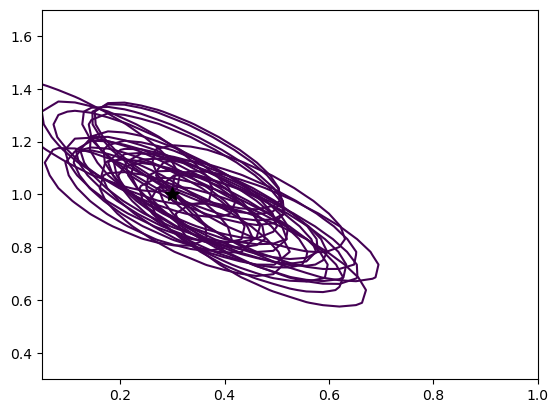

In [62]:
for i in range(30):
    z = ll_ss[:, :, i]
    plt.contour(Sps_dsk_arr, Sps_nfw_arr, z-np.max(z), levels=[-2])
plt.plot([0.3], [1.0], 'k*', ms=10)

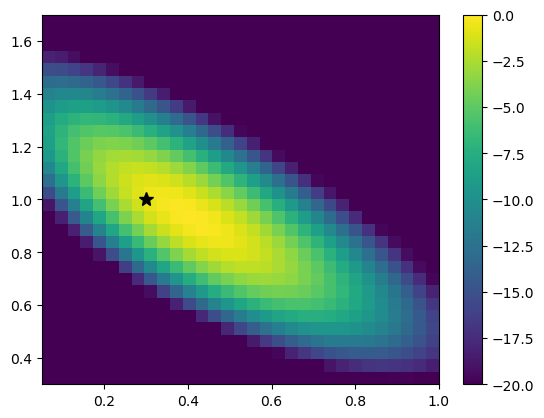

In [65]:
z = ll_ss[:, :, 23]
plt.imshow(z-np.max(z), origin="lower", aspect="auto", extent=[0.05, 1.0, 0.3, 1.7], vmin=-20, vmax=0)
plt.plot([0.3], [1.0], 'k*', ms=10)
plt.colorbar()

# Converage

In [52]:
from scipy import interpolate

def superres(x, y, n_pt=1000):
    x_new = np.linspace(x[0], x[-1], n_pt)
    return x_new, interpolate.CubicSpline(x, y)(x_new)

def find_pdf_hdi_prob(pdf_arr, x_arr=None, x_truth=None, pdf_truth=None):
    """Find the probability for which the HDI includes the truth."""
    if x_truth is not None and x_arr is not None:
        pdf_truth = np.interp(x_truth, x_arr, pdf_arr)
    if pdf_truth is None:
        raise ValueError('Either (x_arr, x_truth) or pdf_truth must be provided.')
    
    return np.sum(pdf_arr[pdf_arr >= pdf_truth]) / np.sum(pdf_arr)

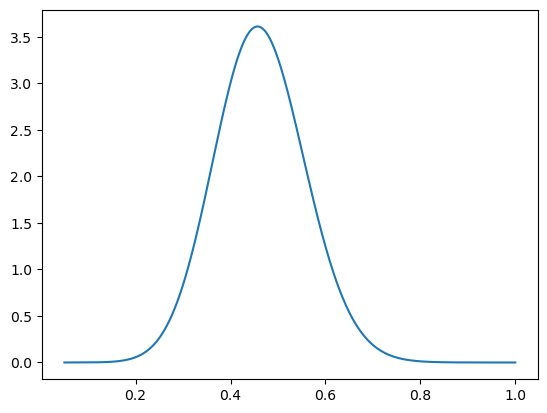

In [70]:
ll = ll_ss[:, :, 0]
pdf = np.exp(ll - np.max(ll))
pdf = np.sum(pdf, axis=0)
amp_sr, pdf_sr = superres(Sps_dsk_arr, pdf, 1000)
plt.plot(amp_sr, pdf_sr)

In [73]:
coverage_dict = {}
n_nan = 0
n_sim = 100

ks = ['Sps_nfw', 'Sps_dsk']
amp_arr_s = [Sps_nfw_arr, Sps_dsk_arr]
axis_to_sum = [1, 0]
coverage_dict = {}

for i, k in enumerate(ks):
    prob_samples = []
    print(k)
    for i_mc in tqdm(range(n_sim)):
        ll = ll_ss[:, :, i_mc]
        pdf_ss = np.exp(ll - np.max(ll))
        pdf_vals = np.sum(pdf_ss, axis=axis_to_sum[i])
        # if np.any(np.isnan(ll_vals)):
        #     n_nan += 1
        #     continue
        amp_rs_s, pdf_rs_s = superres(amp_arr_s[i], pdf_vals, 100)
        #amp_rs_s, ll_rs_s = amp_s, ll_vals
        prob_samples.append(find_pdf_hdi_prob(pdf_rs_s, amp_rs_s, truth_dict[k]))
    p_nominal, p_actual = np.sort(prob_samples), np.linspace(0, 1, len(prob_samples))
    coverage_dict[k] = (p_nominal, p_actual)

Sps_nfw


100%|██████████| 100/100 [00:00<00:00, 5402.80it/s]


Sps_dsk


100%|██████████| 100/100 [00:00<00:00, 5422.01it/s]


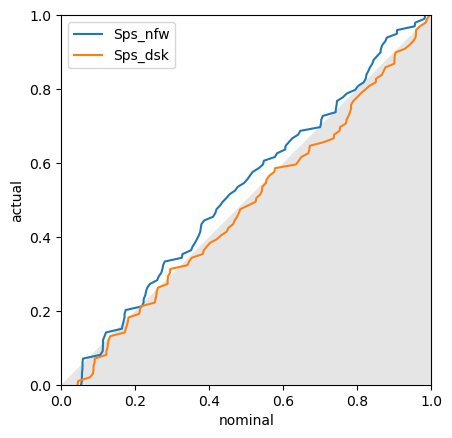

In [74]:
fig, ax = plt.subplots()

for k in ks:
    p_nominal, p_actual = coverage_dict[k]
    ax.plot(p_nominal, p_actual, label=k)
ax.set(aspect='equal', xlabel='nominal', ylabel='actual', xlim=(0, 1), ylim=(0, 1))
ax.fill_between([0, 1], [0, 1], 0, color='gray', alpha=0.2, ec='none')
ax.legend()

# what about SVI? similar to evaluating pdf?

In [77]:
m = NPModelGC2(psf_tags=['deltasimple'])
m.load_data_batch()

Number of pixels in ROI: 6839
Using PSF tags: ['deltasimple']
Max photon count is 103


In [79]:
m.data_in.shape

(100, 196608)

In [84]:
m.fit_svi(n_steps=1000, data=m.data_in[0])
samples = m.get_svi_samples(num_samples=50000)

100%|██████████| 1000/1000 [01:45<00:00,  9.48it/s, init loss: 20602.4143, avg. loss [951-1000]: 20193.7942]


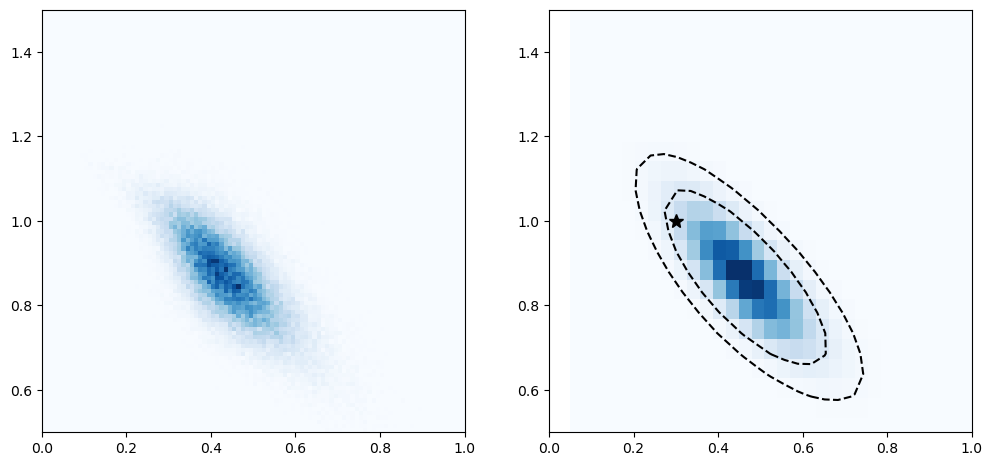

In [98]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

ax = axs[0]
ax.hist2d(samples["Sps_dsk"], samples["Sps_nfw"], bins=100, cmap="Blues", range=[[0, 1], [0.5, 1.5]])
ax.set(aspect=1)

z = ll_ss[:, :, 0]

ax = axs[1]
ax.imshow(np.exp(z-np.max(z)), origin="lower", extent=[0.05, 1.0, 0.3, 1.7], aspect=1, cmap="Blues")
ax.contour(Sps_dsk_arr, Sps_nfw_arr, z-np.max(z), levels=[-4, -2], colors='k')
ax.set(xlim=[0, 1], ylim=[0.5, 1.5])
ax.plot([0.3], [1.0], 'k*', ms=10)